# Logistic Regression

**Logistic Regression** is a **supervised classification algorithm** used to predict a **binary outcome** (yes/no, 0/1, pass/fail, etc.) based on one or more independent variables.

Despite its name, it's used for **classification**, not regression.


<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2012/Session%2012_1%20-%20Model%20Evaluation%20and%20Refinement.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2012/Session%2012_1%20-%20Model%20Evaluation%20and%20Refinement.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>


---

## 🧮 Why Not Linear Regression?

You **cannot use Linear Regression** for binary classification because it can produce predictions outside the \[0, 1] range, which makes no sense for probabilities.

Instead, we use **Logistic Regression**, which maps predictions to a probability using the **logistic (sigmoid) function**.

---

## ⚙️ Logistic Regression Equation

The core idea is to estimate the probability that a given input **belongs to a particular class**.

### 🔢 The Linear Part:

$$
z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n
$$

This is the same as in linear regression: a linear combination of features.

---

### 📈 The Sigmoid (Logistic) Function:

To constrain the output between 0 and 1, we pass `z` through the **sigmoid function**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

So, the predicted probability is:

$$
P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + \cdots + \beta_nx_n)}}
$$

If this probability is **greater than 0.5**, we classify as 1 (positive class), otherwise 0.

---

### 🎯 Decision Boundary

* Logistic regression finds the **best-fitting sigmoid curve** to separate the two classes.
* The **decision boundary** is where `P = 0.5` → $z = 0$.

It can be linear or nonlinear depending on the feature transformations used.

---

#### ✅ Key Assumptions

1. **Binary outcome**: The target variable should be binary (0 or 1).
2. **Linearity in the log-odds**:
   * Logistic regression assumes that the **log-odds** of the dependent variable is a **linear combination** of the independent variables.
3. **No multicollinearity**: Independent variables should not be highly correlated with each other.
4. **Independence of observations**: Each data point should be independent.

---

### 🧪 Model Training (Behind the Scenes)

Logistic Regression uses **Maximum Likelihood Estimation (MLE)** to find the best coefficients (weights) that maximize the probability of observing the data.

Unlike linear regression, it **does not** use the least squares method.

---

### 📊 Logistic Loss Function (Binary Cross-Entropy)

The loss function that logistic regression minimizes is:

$$
\text{Loss} = -\frac{1}{N} \sum_{i=1}^N [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]
$$

This is also called **log loss** or **binary cross-entropy**.

---

### ⚖️ Regularization

To avoid overfitting, logistic regression can include:

* **L1 (Lasso) Regularization** – can zero out less important features
* **L2 (Ridge) Regularization** – penalizes large weights but keeps all features

In scikit-learn, the `LogisticRegression` class supports both via the `penalty` parameter.

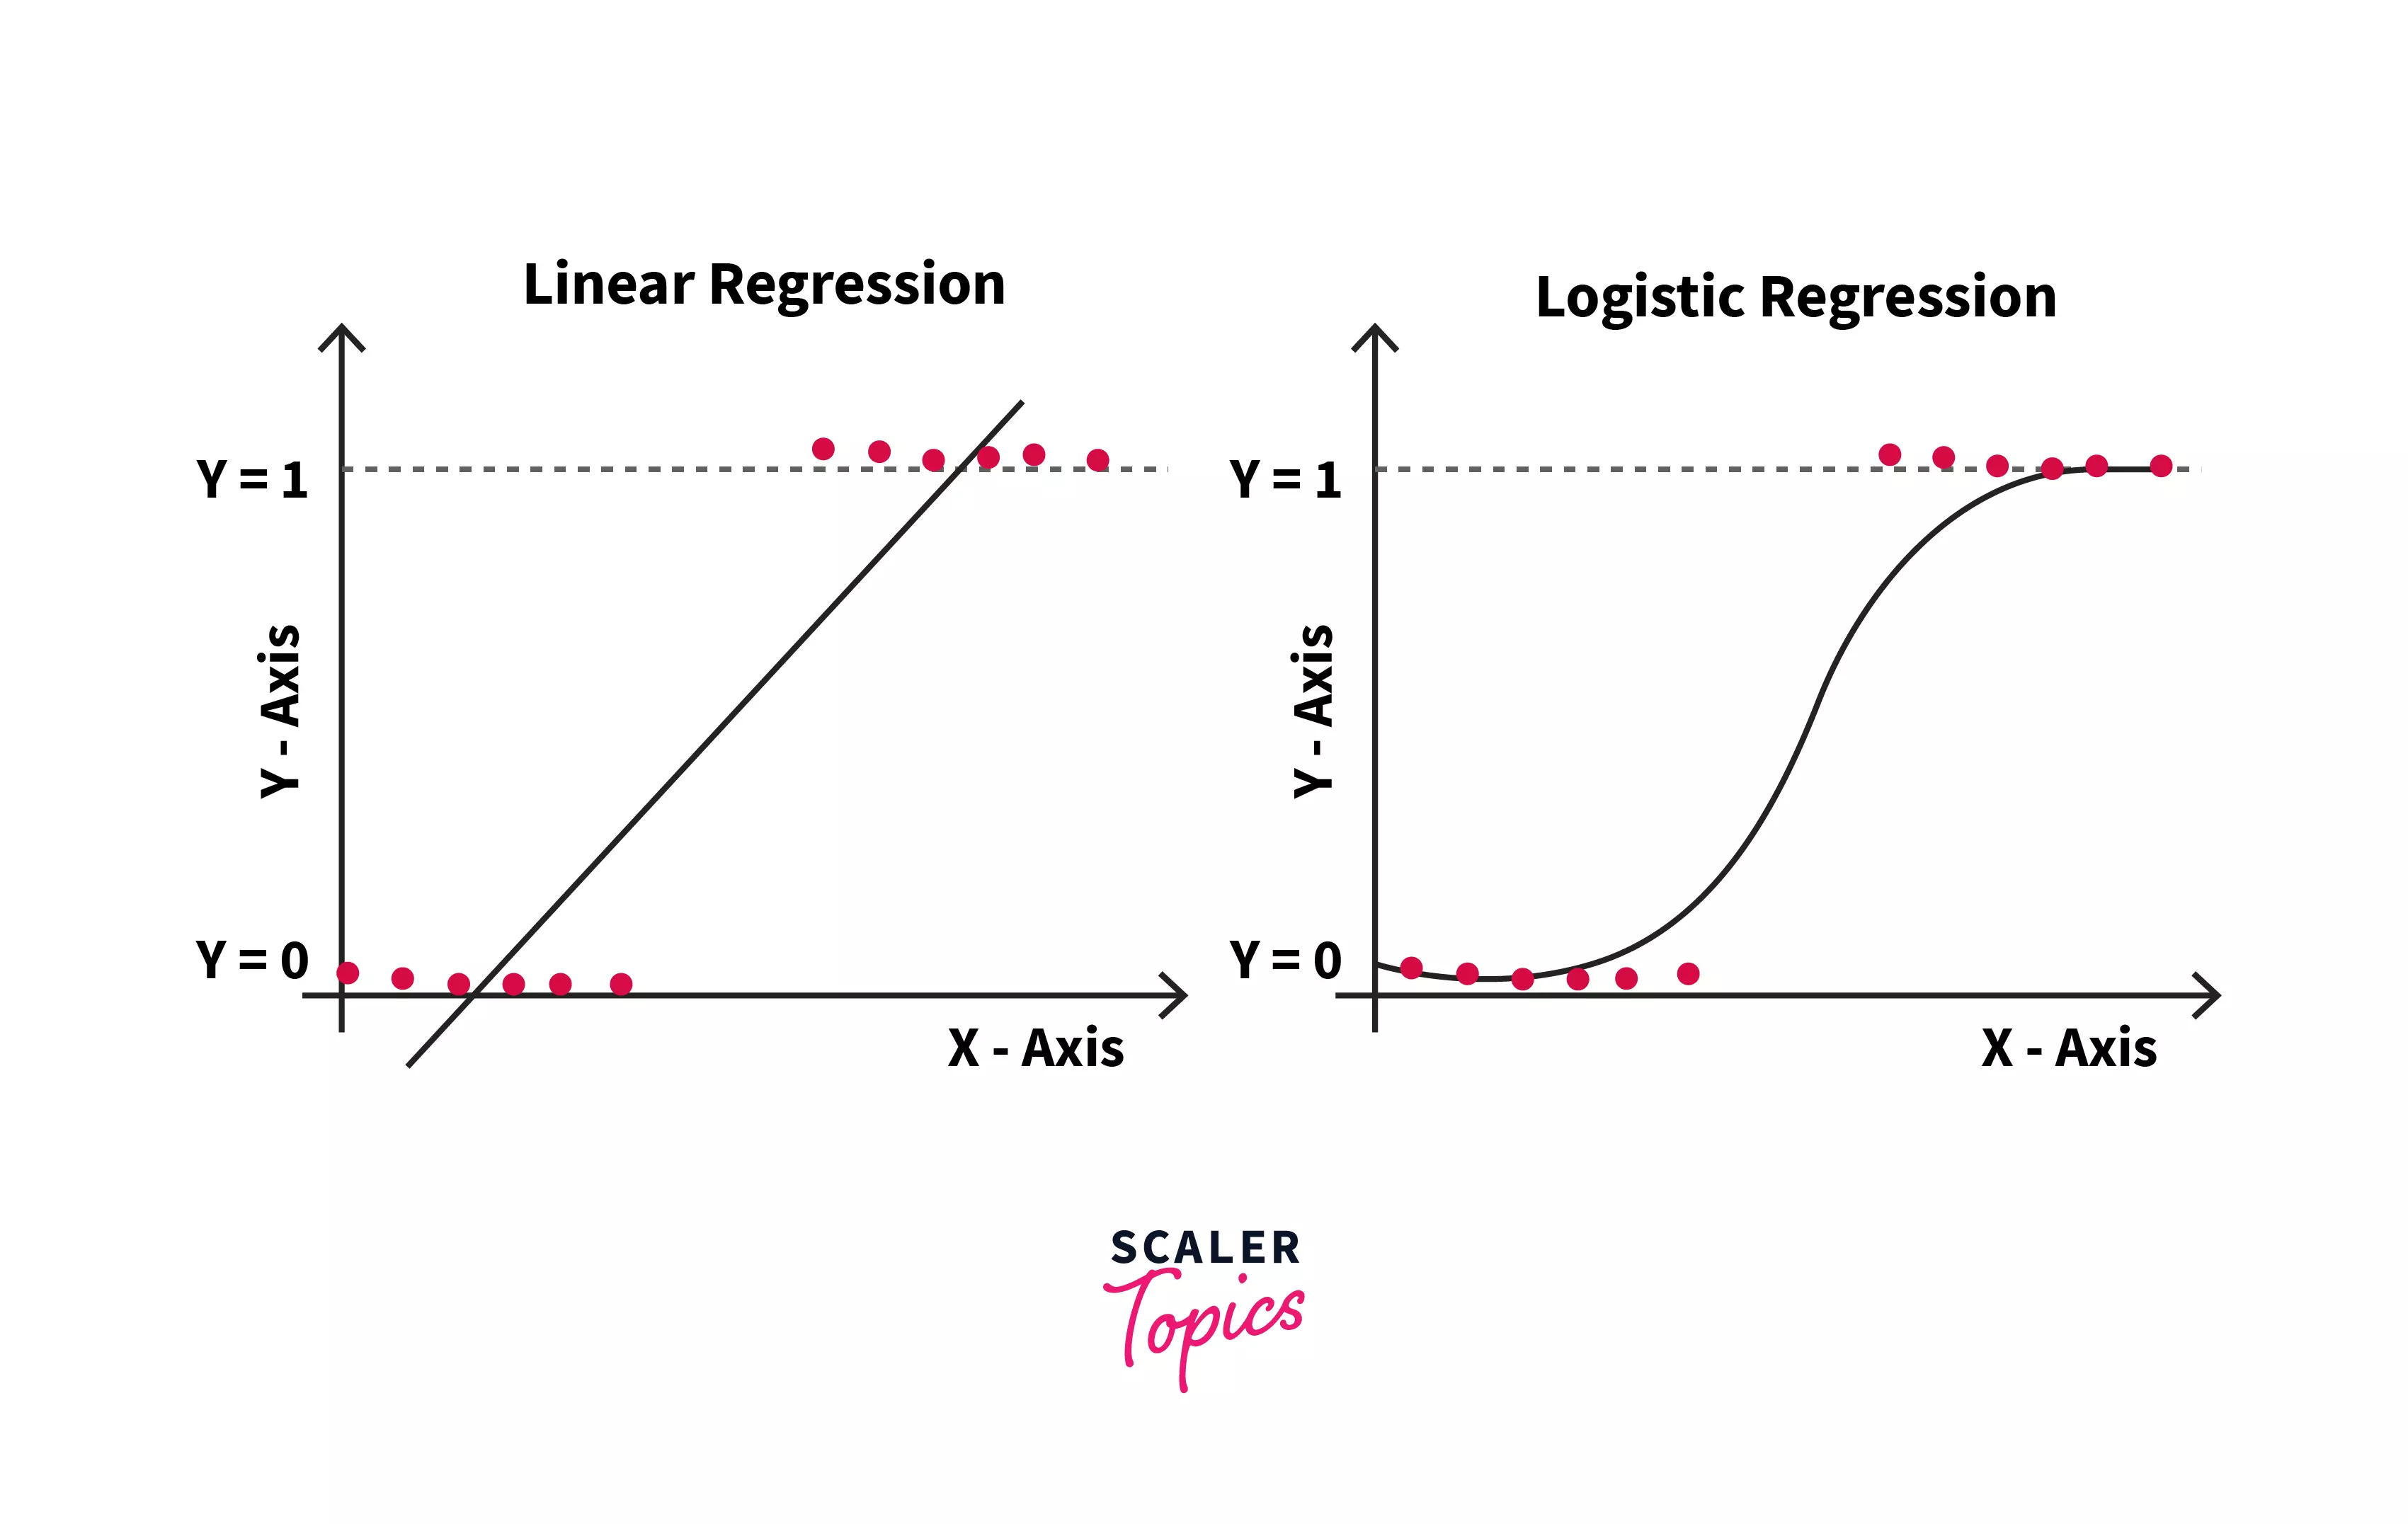

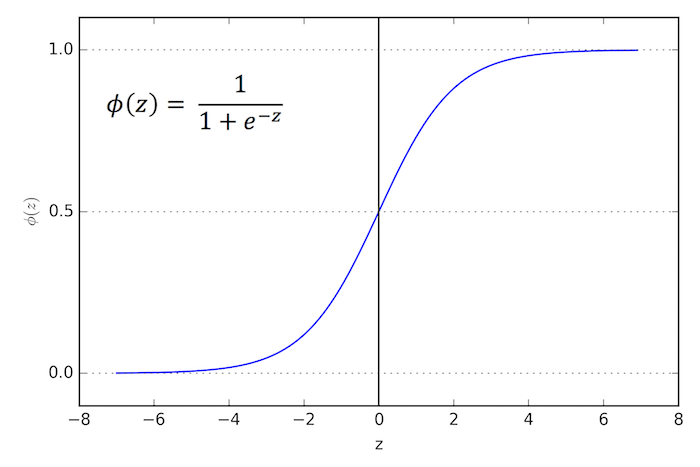

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Exploratory Data Analysis


## Missing Data


<Axes: >

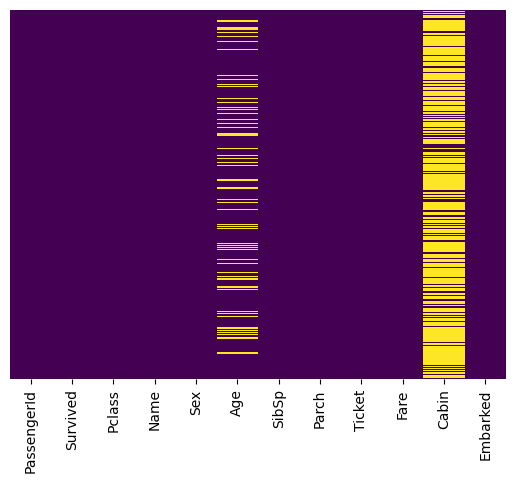

In [3]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [4]:
df[['Age','Survived']].corr()

,Age,Survived
Age,1.000000,-0.077221
Survived,-0.077221,1.000000


Text(0, 0.5, 'Count')

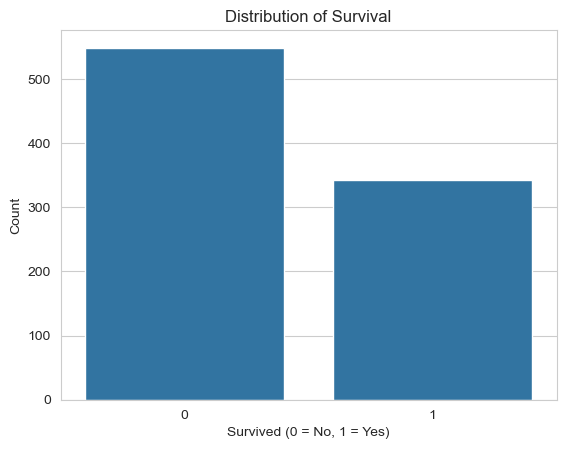

In [5]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=df)
plt.title('Distribution of Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')

Text(0.5, 1.0, 'Survival by Sex')

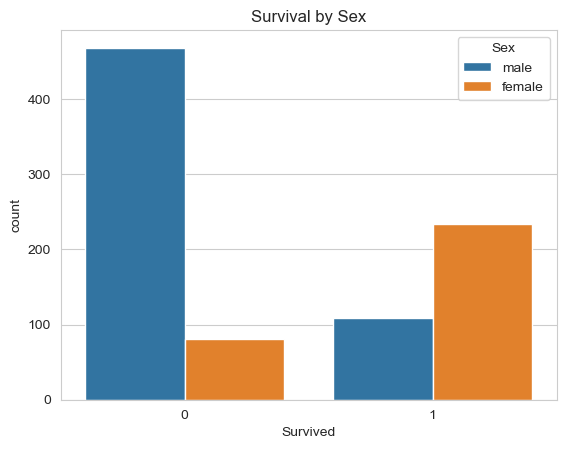

In [6]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by Sex')

Text(0.5, 1.0, 'Survival by Passenger Class')

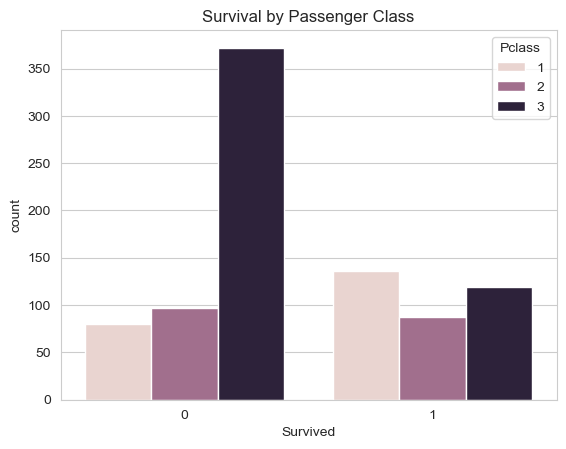

In [7]:
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Survival by Passenger Class')

<Axes: xlabel='Age', ylabel='Count'>

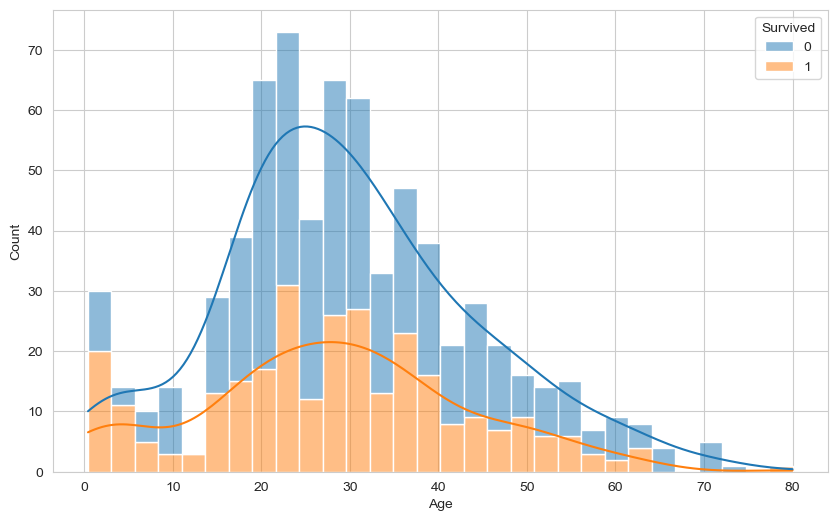

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', bins=30, kde=True, hue='Survived', multiple='stack')

<Axes: >

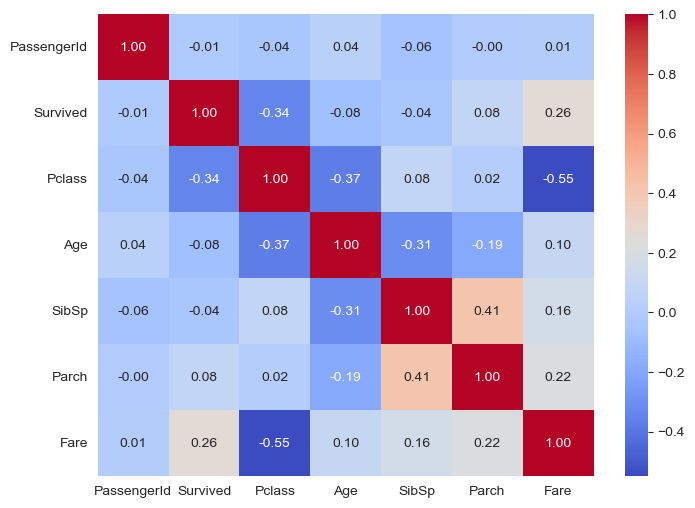

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

## Data Cleaning


<Axes: xlabel='Pclass', ylabel='Age'>

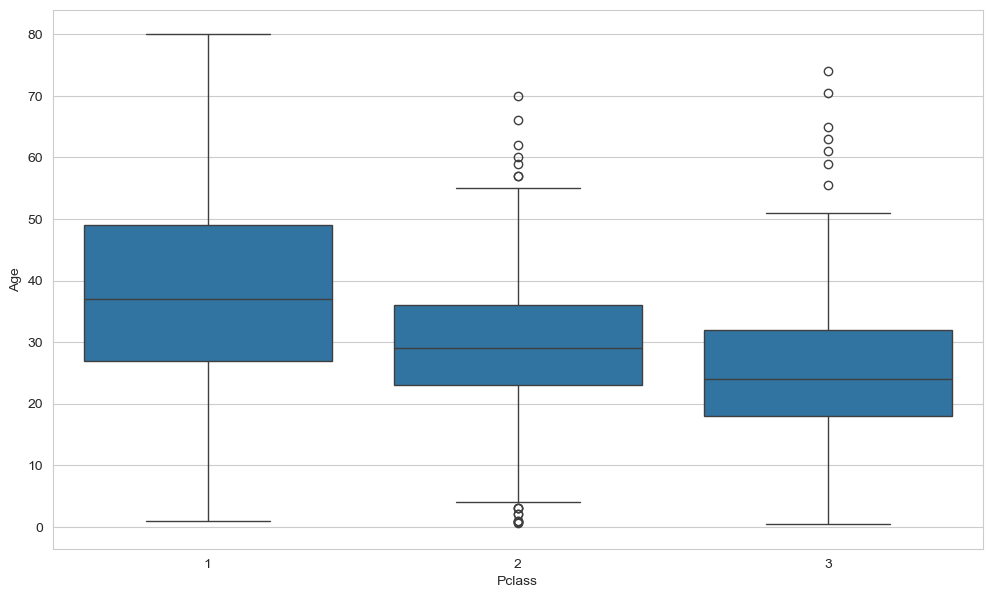

In [10]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass',y='Age',data=df)

We can see the wealthier passengers in the higher classes tend to be older, which makes sense. We'll use these average age values to impute based on Pclass for Age.

In [11]:
def impute_age(cols):
    Age = cols.iloc[0]
    Pclass = cols.iloc[1]
    if pd.isnull(Age):
        if Pclass == 1:
            return df[df['Pclass'] == 1]['Age'].median()
        elif Pclass == 2:
            return df[df['Pclass'] == 2]['Age'].median()
        else:
            return df[df['Pclass'] == 3]['Age'].median()
    else:
        return Age


df['Age'] = df[['Age', 'Pclass']].apply(impute_age, axis=1)

Now let's check that heat map again!

<Axes: >

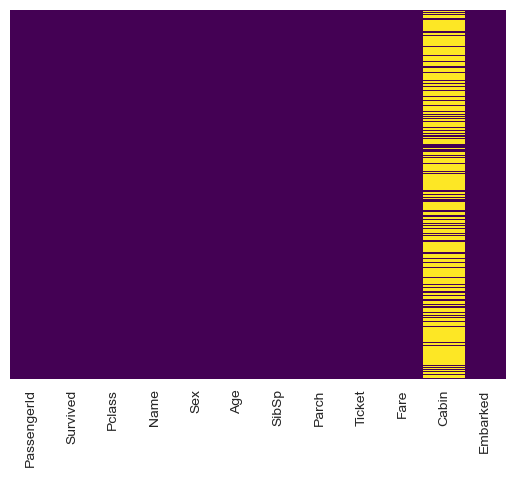

In [12]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

Great! Let's go ahead and drop the Cabin column and the row in Embarked that is NaN.

In [13]:
df.drop('Cabin',axis=1,inplace=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [14]:
df.dropna(inplace=True)

## Converting Categorical Features 

We'll need to convert categorical features to dummy variables using pandas! Otherwise our machine learning algorithm won't be able to directly take in those features as inputs.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [16]:
from sklearn.preprocessing import LabelEncoder

sex = pd.get_dummies(df['Sex'],drop_first=True)

le = LabelEncoder()
df['Embarked'] = le.fit_transform(df['Embarked'])
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

C: 0
Q: 1
S: 2


In [17]:
df.drop(['Sex','Name','Ticket'],axis=1,inplace=True)

In [18]:
train = pd.concat([df,sex],axis=1)

In [19]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,male
0,1,0,3,22.0,1,0,7.2500,2,True
1,2,1,1,38.0,1,0,71.2833,0,False
2,3,1,3,26.0,0,0,7.9250,2,False
3,4,1,1,35.0,1,0,53.1000,2,False
4,5,0,3,35.0,0,0,8.0500,2,True


## Building a Logistic Regression model



### Train Test Split

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived',axis=1), train['Survived'], test_size=0.30)

## 🔧 **LogisticRegression Parameters Explained**

| Parameter               | Type                                 | Description                                                                         |
| ----------------------- | ------------------------------------ | ----------------------------------------------------------------------------------- |
| **`penalty`**           | str, default=`'l2'`                  | Type of regularization: `'l1'`, `'l2'`, `'elasticnet'`, `'none'`.                   |
| **`dual`**              | bool, default=`False`                | Use dual formulation. Only for `penalty='l2'` with `liblinear`.                     |
| **`tol`**               | float, default=`1e-4`                | Tolerance for stopping criteria. Lower = more precise but slower.                   |
| **`C`**                 | float, default=`1.0`                 | Inverse of regularization strength. Smaller values specify stronger regularization. |
| **`fit_intercept`**     | bool, default=`True`                 | Whether to include an intercept (bias term).                                        |
| **`intercept_scaling`** | float, default=`1`                   | Only used when `solver='liblinear'` and `fit_intercept=True`.                       |
| **`class_weight`**      | dict or `'balanced'`, default=`None` | Adjust weights for classes (useful for imbalanced data).                            |
| **`random_state`**      | int or `None`                        | Seed for reproducibility. Affects shuffling and solver randomness.                  |
| **`solver`**            | str, default=`'lbfgs'`               | Optimization algorithm: `'newton-cg'`, `'lbfgs'`, `'liblinear'`, `'sag'`, `'saga'`. |
| **`max_iter`**          | int, default=`100`                   | Max number of iterations to converge. Increase if you get convergence warnings.     |
| **`multi_class`**       | str, default=`'auto'`                | For multiclass problems: `'auto'`, `'ovr'`, `'multinomial'`.                        |
| **`verbose`**           | int, default=`0`                     | If > 0, prints progress during training (debugging).                                |
| **`warm_start`**        | bool, default=`False`                | Reuse previous solution to speed up fitting in loops.                               |
| **`n_jobs`**            | int, default=`None`                  | Number of CPU cores to use (only for some solvers).                                 |
| **`l1_ratio`**          | float or `None`, default=`None`      | Used only when `penalty='elasticnet'`. Between 0 (L2) and 1 (L1).                   |

---

## 🧠 Solver Selection Guide

| Solver        | Supports L1? | Supports L2? | ElasticNet? | Multiclass  |
| ------------- | ------------ | ------------ | ----------- | ----------- |
| `'liblinear'` | ✅            | ✅            | ❌           | One-vs-Rest |
| `'lbfgs'`     | ❌            | ✅            | ❌           | Multinomial |
| `'newton-cg'` | ❌            | ✅            | ❌           | Multinomial |
| `'sag'`       | ❌            | ✅            | ❌           | Multinomial |
| `'saga'`      | ✅            | ✅            | ✅           | Multinomial |

---


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logmodel = LogisticRegression(max_iter=500)
logmodel.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=500)

#### 📈 Interpreting Coefficients

In logistic regression, coefficients ($\beta$) represent the **log-odds**:

$$
\text{Odds} = e^{\beta}
$$

* A **positive** coefficient means increasing that variable increases the log-odds of the target being 1.
* A **negative** coefficient decreases the log-odds.

In [22]:
y_pred = logmodel.predict(X_test_scaled)

## Evaluation

We can check precision,recall,f1-score using classification report!

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

Accuracy Score: 0.8090

Confusion Matrix:
[[141  20]
 [ 31  75]]

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.88      0.85       161
    Survived       0.79      0.71      0.75       106

    accuracy                           0.81       267
   macro avg       0.80      0.79      0.80       267
weighted avg       0.81      0.81      0.81       267



Text(0.5, 1.0, 'Confusion Matrix')

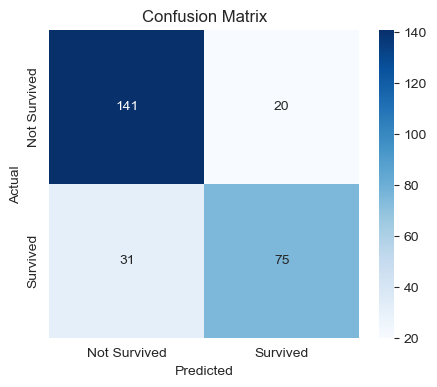

In [24]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

## 🧠 What is AUC?

**AUC** stands for **Area Under the Curve**, and it refers to the **area under the ROC (Receiver Operating Characteristic) curve**.

It is a **single number summary** that tells you how well your model distinguishes between the two classes (e.g., survived vs. not survived).

---

## 🚀 Why is AUC Important?

AUC is a **threshold-independent** metric, meaning it evaluates the model's performance across all possible classification thresholds (not just 0.5). This gives a **more holistic view** than accuracy alone.

A high AUC means the model:

* **Ranks positive instances higher than negative ones**
* **Separates the classes well**

---

The **ROC curve** is built by calculating:

* **TPR (True Positive Rate)** = Sensitivity = Recall

$$
TPR = \frac{TP}{TP + FN}
$$

* **FPR (False Positive Rate)**

$$
FPR = \frac{FP}{FP + TN}
$$

At different thresholds (e.g., 0.9, 0.8, 0.5, 0.1...), you calculate TPR and FPR and plot the **ROC curve**.

---

### **Plot the ROC Curve**

* X-axis: **FPR**
* Y-axis: **TPR**

The ROC curve starts at (0,0) and ends at (1,1).

---

### **AUC = Area under this ROC curve**

The AUC is the **integral (area)** under the ROC curve.

---

### 🎯 Interpreting AUC Values

| AUC Score     | Interpretation                                                |
| ------------- | ------------------------------------------------------------- |
| **1.0**       | Perfect classifier — all positives ranked above all negatives |
| **0.9 - 1.0** | Excellent                                                     |
| **0.8 - 0.9** | Good                                                          |
| **0.7 - 0.8** | Fair                                                          |
| **0.6 - 0.7** | Poor                                                          |
| **0.5**       | No discrimination (like random guessing)                      |
| **< 0.5**     | Model is worse than random (maybe flipped labels!)            |

---


### ⚠️ When AUC Might Be Misleading

* If classes are **highly imbalanced**, AUC may look good even if the model performs poorly on the minority class.
* In such cases, consider **Precision-Recall AUC** as well.


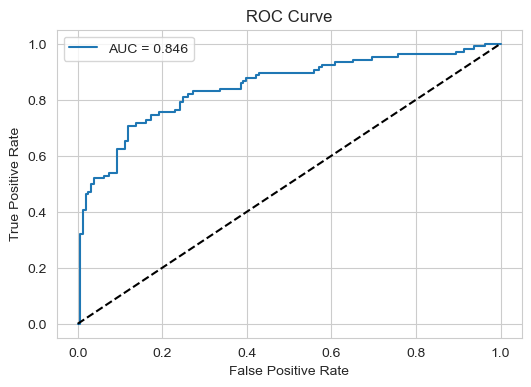

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = logmodel.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2006/Session%2006%20-%20Matplotlib%20Concepts_1.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>